# Earth's Energy Imbalance and Ocean Heat Content

Earth absorbs energy from the Sun and emits energy back to space.

- What happens when these two fluxes are not equal?
- If Earth is gaining energy, where does that excess energy go?

In this activity, we use ocean observations to investigate how Earth stores excess energy, and how ocean observations help us understand Earth's energy imbalance.

Data sources: Argovis (`grids/rg09`, `timeseries/noaasst`) and the GCOS Earth Heat Inventory (von Schuckmann et al. 2023, *Earth System Science Data*, [essd.copernicus.org/articles/15/1675/2023](https://essd.copernicus.org/articles/15/1675/2023/)).


## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Fill out the form under **New Account Registration**
3. An API key will be emailed to you shortly

Treat your API key like a password — don't share it or leave it anywhere public. If you ever forget it or accidentally reveal it, visit the same website to change or deactivate your token.

Set `APIKEY` in the cell below before running anything else. The notebook may still work with `'guest'` but may return errors under heavy load.

## Setup: imports

In [1]:
from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
import numpy as np
import xarray as xr
import gsw
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

APIKEY  = 'guest'   # ← paste your key here
APIROOT = 'https://argovis-api.colorado.edu/'


## Helper functions

- `traverse_query` — loop over region × time × dataset, call the API
- `tidy_grid` — sort/clean a queried grid's dimensions
- `spatial_average` — cos-latitude-weighted mean over a region
- `derive_TS_grid` — SA, CT, σ₀ via TEOS-10
- `compute_ohc_profile` — OHC (0–depth_max), vertical integral on the fly
- `compute_linear_trend` — linear trend, vectorized over lon/lat (used for the trend maps)
- `plot_maps` — scatter locations on a map
- `plot_ohc_trend_map` — trend map, diverging colormap (reused for both the SST and OHC trend maps)
- `plot_gcos_ohc_layers` — GCOS depth-layer OHC time series
- `annual_mean_dropping_incomplete` — annual mean, dropping any year with too few samples
- `plot_multi_region_timeseries` — one time series per region, overlaid on a single panel
- `plot_eei_components` — stacked chart of Earth-system heat-content components (atmosphere/land/cryosphere/ocean)


In [2]:
from notebook_helpers.functions import traverse_query, plot_maps
from notebook_helpers.functions_SLA import tidy_grid
from notebook_helpers.functions_candidates_for_functions import spatial_average
from notebook_helpers.functions_MHW import derive_TS_grid, compute_ohc_profile, compute_linear_trend
from notebook_helpers.functions_WARMING import plot_gcos_ohc_layers, plot_ohc_trend_map
from notebook_helpers.functions_EEI import (
    annual_mean_dropping_incomplete, plot_multi_region_timeseries, plot_eei_components,
)


## Configuration

Three contrasting regions (as in the companion activity), 2004–2023 (max range common to `grids/rg09` and `timeseries/noaasst`), aggregated to **annual** means so short-term variability (e.g. ENSO in the equatorial Pacific) doesn't obscure the long-term signal in the comparison plots below.

- **NW Atlantic** — rapid-warming hot-spot (Gulf Stream extension)
- **Central N. Pacific** — calm subtropical gyre
- **Equatorial Pacific** — ENSO-dominated variability

The trend maps use a separate, smaller region (`TREND_REGION_BOX`) and a separate 10-year period (`TREND_TIME_PERIOD`) — confirmed directly against Argovis to be safe for **both** `grids/rg09` and the weekly `timeseries/noaasst` together, so the SST and OHC trend maps cover the exact same area and period and are directly comparable.


In [3]:
# MODIFY HERE
REGIONS = {
    'NW Atlantic':        {'box': [[-52.0, 38.0], [-48.0, 42.0]]},
    'Central N. Pacific':  {'box': [[-155.0, 25.0], [-151.0, 29.0]]},
    'Equatorial Pacific':  {'box': [[-172.0, -3.0], [-168.0, 3.0]]},
}
TIME_PERIOD = {'startDate': '2004-01-01T00:00:00Z', 'endDate': '2023-01-31T00:00:00Z'}

OHC_DEPTH = 300   # regional, on-the-fly OHC (matches compute_ohc_profile's own default)

TREND_REGION_BOX  = [[-50.0, 40.0], [-30.0, 50.0]]
TREND_TIME_PERIOD = {'startDate': '2014-01-01T00:00:00Z', 'endDate': '2024-01-01T00:00:00Z'}

GCOS_PATH = 'GCOS_EHI_1960-2020_Earth_Heat_Inventory_Ocean_Heat_Content_data.nc'

regions      = list(REGIONS.values())
region_names = list(REGIONS.keys())
time_periods = [TIME_PERIOD]
grids_region = {'grids/rg09': 'rg09_temperature,rg09_salinity', 'timeseries/noaasst': 'sst'}

trend_regions      = [{"box": TREND_REGION_BOX}]
trend_time_periods = [TREND_TIME_PERIOD]


### Step 1 — Query NOAA SST and RG09 on all three regions

In [4]:
from datetime import datetime
print("Current Time =", datetime.now().strftime("%H:%M:%S"))


Current Time = 16:00:58


In [5]:
grid_results = traverse_query(regions, time_periods, grids_region, avh.queryGrid, APIKEY, APIROOT)

print('Queried:', list(grid_results))


Queried: ['grids/rg09', 'timeseries/noaasst']


In [6]:
from datetime import datetime
print("Current Time =", datetime.now().strftime("%H:%M:%S"))


Current Time = 16:01:28


## Map — the three regions queried above

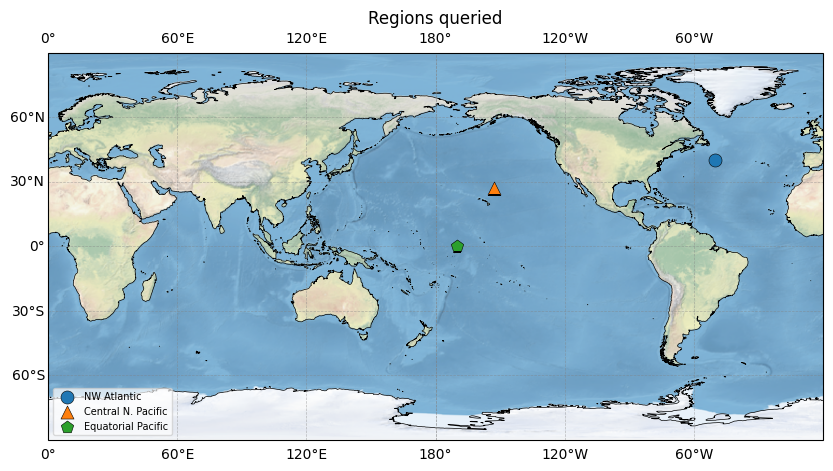

<GeoAxes: title={'center': 'Regions queried'}>

In [7]:
region_lats = [[(REGIONS[name]['box'][0][1] + REGIONS[name]['box'][1][1]) / 2] for name in region_names]
region_lons = [[(REGIONS[name]['box'][0][0] + REGIONS[name]['box'][1][0]) / 2] for name in region_names]

plot_maps(
    region_lats, region_lons,
    title='Regions queried',
    labels=region_names, markersize=6,
    global_view=True, central_longitude=180,
)


### Step 2 — Derive annual SST and OHC per region

In [8]:
regional_sst_annual = {}
regional_ohc_annual = {}

for name in region_names:
    lon_band = (REGIONS[name]['box'][0][0], REGIONS[name]['box'][1][0])
    lat_band = (REGIONS[name]['box'][0][1], REGIONS[name]['box'][1][1])
    lon0, lat0 = np.mean(lon_band), np.mean(lat_band)
    r_i = region_names.index(name)

    temp_rg  = tidy_grid(grid_results['grids/rg09'][r_i][0].rg09_temperature)
    salt_rg  = tidy_grid(grid_results['grids/rg09'][r_i][0].rg09_salinity)
    sst_grid = tidy_grid(grid_results['timeseries/noaasst'][r_i][0].sst).squeeze('level')

    T_prof = spatial_average(temp_rg, lat_band, lon_dim='longitude')
    S_prof = spatial_average(salt_rg, lat_band, lon_dim='longitude')
    SA, CT, SIG0 = derive_TS_grid(T_prof, S_prof, lon0, lat0)

    sst_ts = spatial_average(sst_grid, lat_band, lon_dim='longitude')
    ohc_ts = compute_ohc_profile(CT, SIG0, depth_max=OHC_DEPTH)

    regional_sst_annual[name] = annual_mean_dropping_incomplete(sst_ts)
    regional_ohc_annual[name] = annual_mean_dropping_incomplete(ohc_ts)


## 1. The Ocean Surface: Sea-Surface Temperature

Sea-surface temperature (SST) tells us about the temperature of the ocean surface. Explore SST observations at different locations.

**Questions**
- Where is the ocean warming most?
- Does the pattern of SST change appear to be the same everywhere?
- If we want to determine where the ocean is gaining the most heat, is SST alone enough? Why or why not?


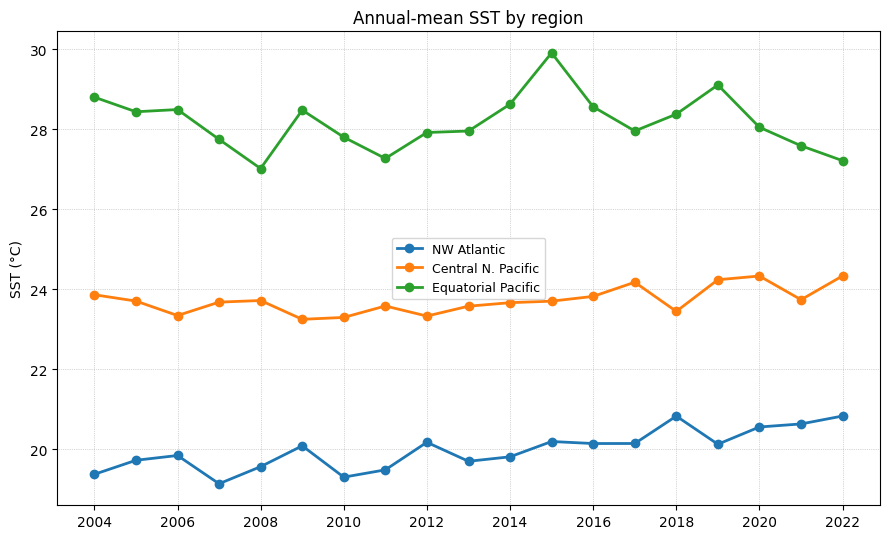

In [9]:
plot_multi_region_timeseries(
    regional_sst_annual, ylabel='SST (°C)', title='Annual-mean SST by region',
)


### SST trend map

Rather than reproduce a figure from a paper, we build our own SST trend map directly from Argovis — over the same region and period used for the OHC trend map below, so the two are directly comparable.

> For the published, global version of this map (observed SST change rate, plus CMIP6 model comparisons and projections), see **Figure 9.3** in IPCC AR6 WG1 Chapter 9 (Fox-Kemper et al., 2021), [ipcc.ch/report/ar6/wg1/figures/chapter-9](https://www.ipcc.ch/report/ar6/wg1/figures/chapter-9/).


### Step 3 — Query NOAA SST on the trend-map region

In [10]:
trend_sst_results = traverse_query(trend_regions, trend_time_periods,
                                   {'timeseries/noaasst': 'sst'}, avh.queryGrid, APIKEY, APIROOT)

print('Queried:', list(trend_sst_results))


Queried: ['timeseries/noaasst']


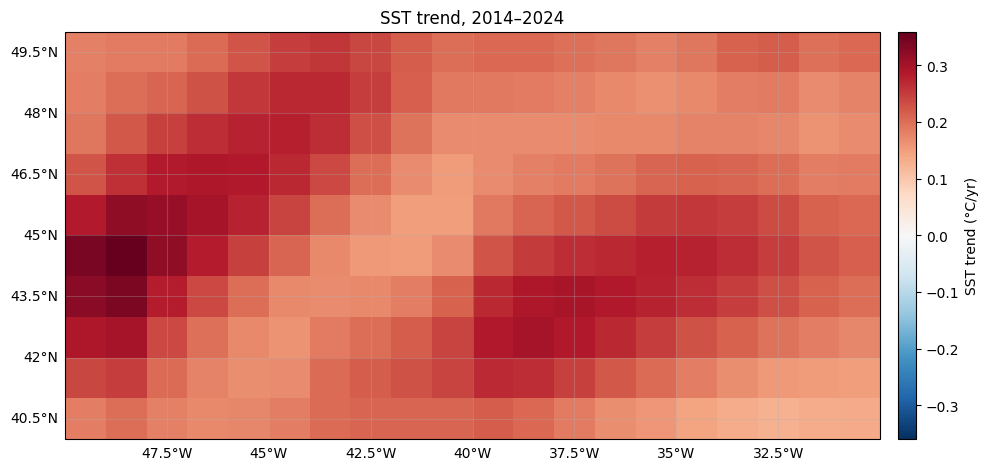

In [11]:
sst_trend_grid = tidy_grid(trend_sst_results['timeseries/noaasst'][0][0].sst).squeeze('level')
sst_trend = compute_linear_trend(sst_trend_grid, per='year')

plot_ohc_trend_map(
    sst_trend,
    title=f'SST trend, {TREND_TIME_PERIOD["startDate"][:4]}–{TREND_TIME_PERIOD["endDate"][:4]}',
    cbar_label='SST trend (°C/yr)',
)


### Temperature vs. heat content

Imagine two locations:
- **Location A** — the upper 10 m of the ocean warms by 2 °C.
- **Location B** — the upper 500 m of the ocean warms by 0.5 °C.

Which location has gained more heat? How could you determine this?

**Key idea:** a change in temperature is not the same as a change in heat content.


*Double-click to edit this cell and write your answer.*

## 2. Looking Below the Surface: Ocean Heat Content

The ocean stores heat throughout its water column, not just at the surface. Ocean heat content (OHC) describes the amount of thermal energy stored in seawater — it depends on temperature change throughout the water column, and the physical properties and amount of seawater involved. SST describes the surface; OHC accounts for heat stored below it.

> For the published, global version of the OHC trend maps and time series built below, see **Figure 9.6, "Ocean Heat Content (OHC) Anomalies and Maps"** in IPCC AR6 WG1 Chapter 9 (Fox-Kemper et al., 2021), [ipcc.ch/report/ar6/wg1/figures/chapter-9](https://www.ipcc.ch/report/ar6/wg1/figures/chapter-9/) — it shows global-mean OHC (multiple observational products and CMIP6 models) alongside global trend maps at 0–700 m and 0–2000 m.

**Questions**
- Is the OHC long-term change in the same direction as the SST long-term change?
- Does the spatial pattern of OHC change look the same as the pattern of SST change?
- Where do the two observations differ?
- What might explain these differences?


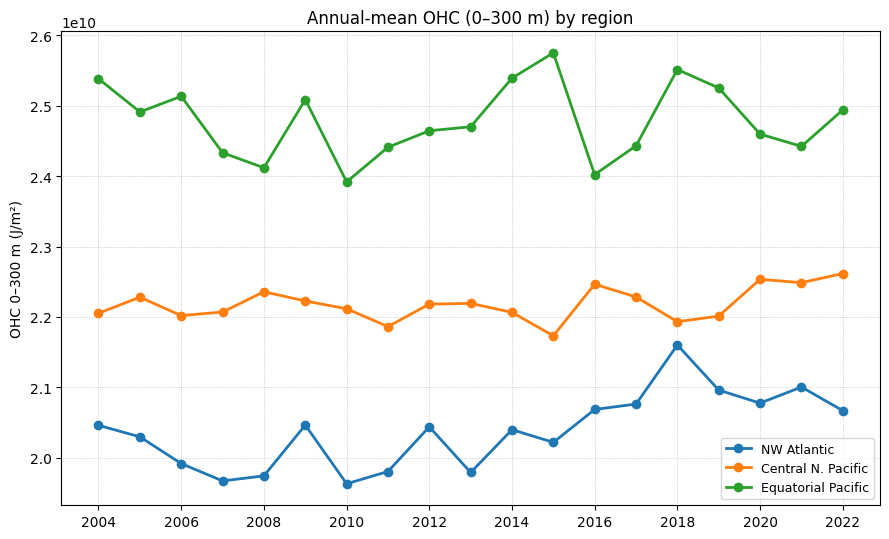

In [12]:
plot_multi_region_timeseries(
    regional_ohc_annual, ylabel=f'OHC 0–{OHC_DEPTH} m (J/m²)', title=f'Annual-mean OHC (0–{OHC_DEPTH} m) by region',
)


### Step 4 — Query RG09 on the trend-map region, and compute the OHC trend map

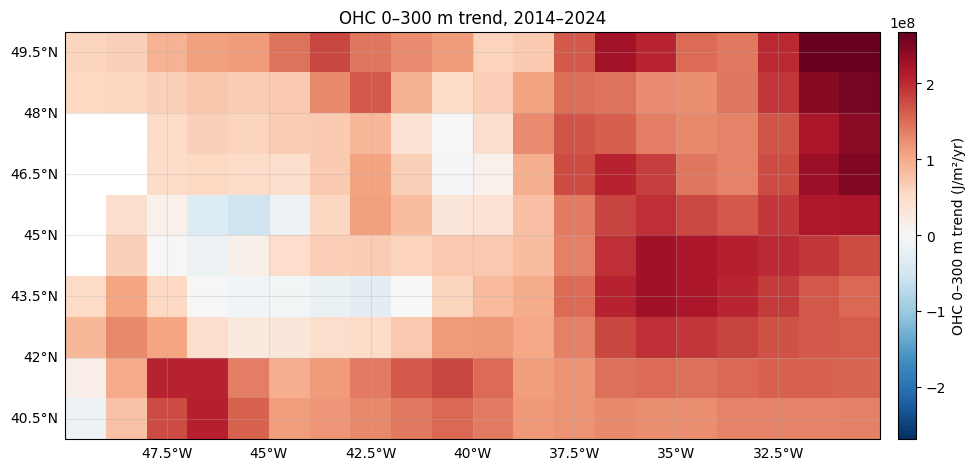

In [13]:
trend_ohc_results = traverse_query(trend_regions, trend_time_periods,
                                   {'grids/rg09': 'rg09_temperature,rg09_salinity'}, avh.queryGrid, APIKEY, APIROOT)

temp_grid = tidy_grid(trend_ohc_results['grids/rg09'][0][0].rg09_temperature)
salt_grid = tidy_grid(trend_ohc_results['grids/rg09'][0][0].rg09_salinity)

lon0 = (TREND_REGION_BOX[0][0] + TREND_REGION_BOX[1][0]) / 2
lat0 = (TREND_REGION_BOX[0][1] + TREND_REGION_BOX[1][1]) / 2
SA_map, CT_map, SIG0_map = derive_TS_grid(temp_grid, salt_grid, lon0, lat0)

ohc_map   = compute_ohc_profile(CT_map, SIG0_map, depth_max=OHC_DEPTH)
ohc_trend = compute_linear_trend(ohc_map, per='year')

plot_ohc_trend_map(
    ohc_trend,
    title=f'OHC 0–{OHC_DEPTH} m trend, {TREND_TIME_PERIOD["startDate"][:4]}–{TREND_TIME_PERIOD["endDate"][:4]}',
    cbar_label=f'OHC 0–{OHC_DEPTH} m trend (J/m²/yr)',
)


*Double-click to edit this cell and write your answer.*

## 3. How Deep Does the Heat Go?

Ocean heat can be transported below the surface. The GCOS Earth Heat Inventory breaks OHC into depth layers: **0–300 m, 0–700 m, 0–2000 m, 700–2000 m, and below 2000 m**. IPCC AR6 WG1 Figure 9.6 (cited above) makes the same 0–700 m vs. 0–2000 m comparison globally, across multiple observational products.

**Questions**
- Does ocean warming occur only at the surface?
- How does heat storage change with depth?
- What would we miss if we only measured SST? What would we miss if we only measured the upper ocean?
- Do we need observations throughout the water column? Why, or why not?


In [14]:
gcos = xr.open_dataset(GCOS_PATH)
print(f"Variables: {list(gcos.data_vars)}")
print(f"Time range: {str(gcos.time.values[0])[:10]} to {str(gcos.time.values[-1])[:10]}  (n={gcos.sizes['time']})")


Variables: ['total_heat_content', 'total_heat_content_uncertainty', 'atmospheric_heat_content', 'atmospheric_heat_content_uncertainty', 'atmospheric_heat_content_coverage_factor', 'continental_heat_content', 'continental_heat_content_uncertainty', 'cryosphere_heat_content', 'cryosphere_heat_content_uncertainty', 'ocean_heat_content_0-300m', 'ocean_heat_content_0-300m_uncertainty', 'ocean_heat_content_0-700m', 'ocean_heat_content_0-700m_uncertainty', 'ocean_heat_content_0-2000m', 'ocean_heat_content_0-2000m_uncertainty', 'ocean_heat_content_700-2000m', 'ocean_heat_content_700-2000m_uncertainty', 'ocean_heat_content_below_2000m', 'ocean_heat_content_below_2000m_uncertainty']
Time range: 1960-06-30 to 2020-06-30  (n=61)


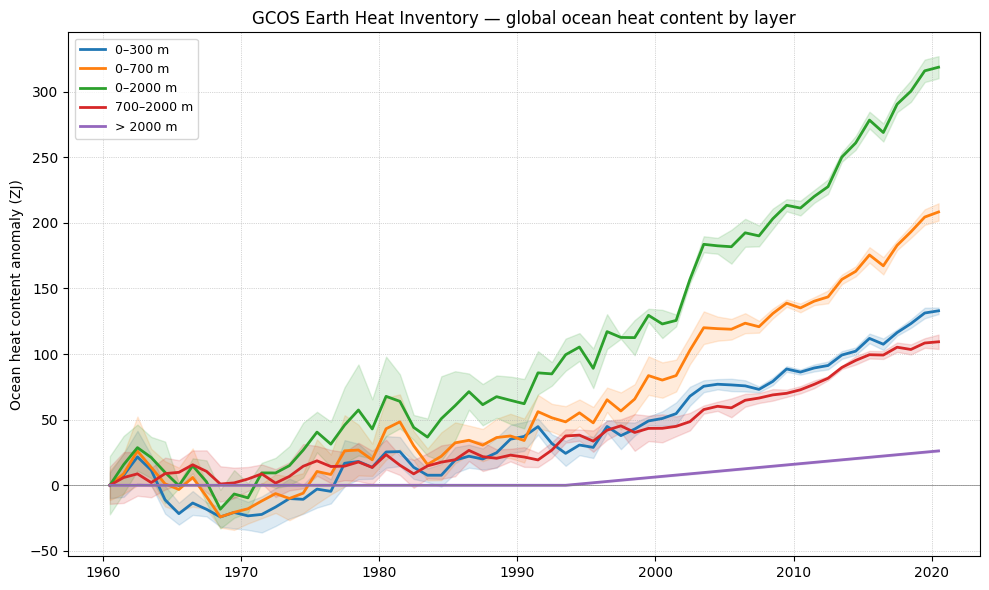

In [15]:
GCOS_LAYERS = ['ocean_heat_content_0-300m', 'ocean_heat_content_0-700m',
              'ocean_heat_content_0-2000m', 'ocean_heat_content_700-2000m',
              'ocean_heat_content_below_2000m']
GCOS_LABELS = ['0–300 m', '0–700 m', '0–2000 m', '700–2000 m', '> 2000 m']

plot_gcos_ohc_layers(gcos, GCOS_LAYERS, labels=GCOS_LABELS)


*Double-click to edit this cell and write your answer.*

## 4. From Temperature to Ocean Heat Content

To estimate how much heat is stored in the ocean, we need to account for the amount of water involved and its temperature — not temperature alone.

$$\text{OHC} = c_p \int \rho(z)\, T(z) \, dz$$

where $c_p$ is the specific heat of seawater, $\rho$ is density, and $T$ is temperature, integrated over depth. This is exactly what `compute_ohc_profile` computes above — it is a genuine vertical integral, not a simple temperature average.

**Questions**
- How does the amount of heat stored change if the temperature change is larger?
- Why is information about the vertical structure of the ocean important for estimating heat content?


*Double-click to edit this cell and write your answer.*

## 5. From One Location to the Whole Ocean

The trend maps above already show that OHC varies spatially. To estimate the *total* heat stored in the ocean, we need to combine information across the ocean:
- **Vertical integration** accounts for heat stored throughout the water column.
- **Horizontal integration** accounts for heat stored across the ocean basin, or the global ocean.

Together, vertical and horizontal integration give an estimate of total ocean heat content.

**Questions**
- Can observations from one location tell us how much heat the global ocean has gained? Why, or why not?
- What information would we need to estimate the total amount of heat stored in the ocean?
- Why do we need observations at many different locations? Why is the spatial distribution of OHC important?


*Double-click to edit this cell and write your answer.*

## 6. Global Ocean Heat Content and Ocean Heat Uptake

**Questions**
- Is global ocean heat content increasing or decreasing?
- What does the slope of the OHC time series tell us?
- What does an increase in global OHC tell us about the amount of energy being stored in the ocean?
- What is the difference between ocean heat content and ocean heat uptake?

**Ocean heat content (OHC)** describes the amount of heat stored in the ocean. **Ocean heat uptake (OHU)** describes the *rate* at which the ocean gains heat — i.e. the slope of the OHC time series.


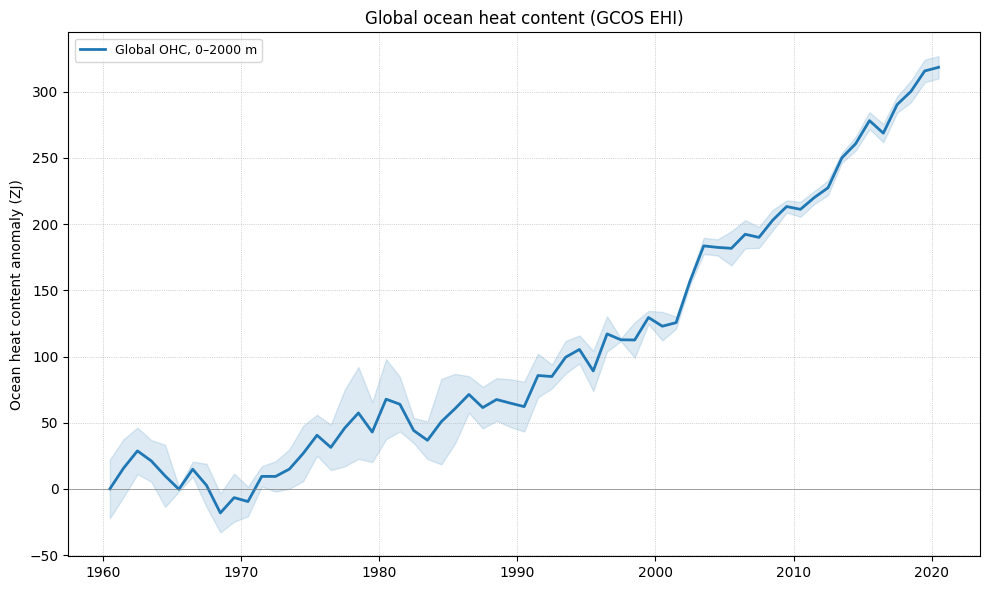

In [16]:
plot_gcos_ohc_layers(
    gcos, ['ocean_heat_content_0-2000m'], labels=['Global OHC, 0–2000 m'],
    title='Global ocean heat content (GCOS EHI)',
)


*Double-click to edit this cell and write your answer.*

## 7. Earth's Energy Imbalance

Earth receives energy from the Sun and loses energy to space. If Earth absorbs more energy than it loses, it has a **positive** Earth's energy imbalance (EEI) and the Earth system gains energy. If Earth loses more energy than it absorbs, EEI is **negative** and the Earth system loses energy.

**Questions**
- What does a positive EEI mean? What does a negative EEI mean?
- If Earth has a positive EEI, where can the excess energy be stored?
- Which components of the Earth system can gain or lose energy?


*Double-click to edit this cell and write your answer.*

## 8. Where Does the Excess Energy Go?

Rather than reproducing Fig. 8 of von Schuckmann et al. (2023) directly, we build the same comparison from the GCOS file's own component data: atmosphere, land (continental), cryosphere, and ocean.

> **Cross-Chapter Box 9.1, "Global energy inventory and sea level budget,"** in IPCC AR6 WG1 Chapter 9, covers the same Earth-system energy-inventory comparison — see [ipcc.ch/report/ar6/wg1/figures/chapter-9](https://www.ipcc.ch/report/ar6/wg1/figures/chapter-9/).

**Question**
Which part of the Earth system stores most of the excess energy associated with a positive EEI?

**Think about what you've learned:** why is ocean heat content such an important quantity for understanding Earth's energy imbalance?

**Key idea:** the ocean stores the overwhelming majority of the excess energy accumulating in the Earth system — about 89%, per von Schuckmann et al. (2023). Changes in OHC are therefore a critical way to track changes in Earth's energy imbalance.


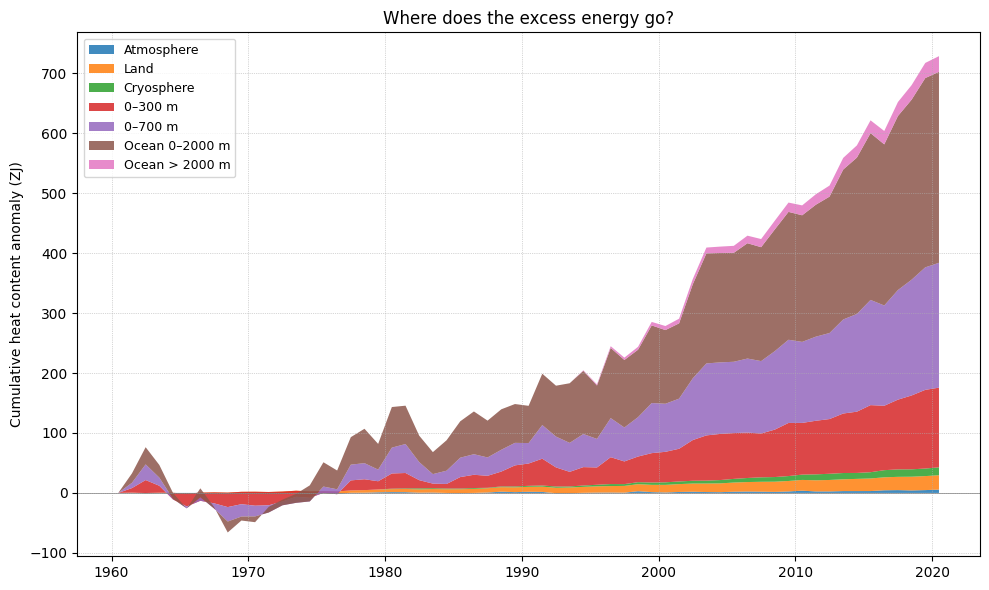

In [20]:
EEI_COMPONENTS = ['atmospheric_heat_content', 'continental_heat_content',
                  'cryosphere_heat_content', 'ocean_heat_content_0-300m', 'ocean_heat_content_0-700m',
                  'ocean_heat_content_0-2000m',
                  'ocean_heat_content_below_2000m']
EEI_LABELS = ['Atmosphere', 'Land', 'Cryosphere', '0–300 m', '0–700 m', 'Ocean 0–2000 m', 'Ocean > 2000 m']

plot_eei_components(gcos, EEI_COMPONENTS, labels=EEI_LABELS)


*Double-click to edit this cell and write your answer.*

## 9. Can We Measure Earth's Energy Imbalance from Space?

Satellites measure radiation entering and leaving the Earth system at the top of the atmosphere. In principle, EEI is the difference between incoming and outgoing energy.

**Questions**
- What quantities would satellites need to measure to determine EEI?
- Incoming and outgoing radiative fluxes are each hundreds of watts per square meter, while EEI itself is much smaller (roughly 1 W/m²). Why does this make the measurement challenging?

EEI is a relatively small difference between two much larger quantities, so determining its absolute, time-mean value requires extremely accurate measurement and calibration. Satellite observations are nevertheless very useful for detecting *changes* and *variability* in EEI.

**Questions**
- Why might we be more confident in changes in EEI than in its absolute time-mean value?
- What would we expect changes in EEI to look like if Earth's energy imbalance varies over time?


*Double-click to edit this cell and write your answer.*

## 10. Comparing Space-Based and Ocean-Based Observations

Ocean observations provide an independent way to investigate changes in EEI. Figure 1 of **Mayer et al. (2026), "The Atmosphere's Substantial Role in Interannual Variability of Earth's Energy Imbalance"**, *Geophysical Research Letters* ([doi.org/10.1029/2025GL119833](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2025GL119833)), compares satellite-derived net top-of-atmosphere radiative flux against ocean heat uptake over 2005–2024.

> **Note:** this comparison needs satellite radiation-budget data (e.g. CERES EBAF), which isn't available through Argovis or the GCOS ocean file used above — so this section is a citation rather than a plot built from our own data, unlike the rest of this notebook.

**Questions**
- Do the two records vary in a similar way? What features do they have in common?
- Why might the two records not match perfectly at every time?
- What does agreement between two independent types of observations tell us about changes in EEI?

The two approaches are complementary: satellite observations describe changes in Earth's radiation budget; ocean observations describe changes in heat stored in the ocean. Together, they provide evidence about how Earth's energy imbalance changes over time.


*Double-click to edit this cell and write your answer.*

## Putting It All Together

If Earth is gaining energy, where does that excess energy go, and how can we measure it?


*Double-click to edit this cell and write your answer.*